# A spiral pays for its long readout in off-resonance

[`../gre_radial_2d/02`](../gre_radial_2d/02_simulate_and_reconstruct.ipynb) built the
non-Cartesian reconstruction and this notebook **changes none of it** — same
[`../noncartesian_recon.py`](../noncartesian_recon.py), same adapter, same solve. What changes is
the acquisition, in exactly one way that matters:

$$\varphi = 2\pi\,\Delta f \cdot T_{\mathrm{read}}$$

A radial spoke is 1.3 ms long, so a 100 Hz offset turns an eighth of a cycle across it and nothing
visible happens. [`01`](01_build.ipynb) wrote a **single-shot spiral** whose readout is 21.7 ms.
The same 100 Hz turns **2.17 cycles**, and that is the whole notebook.

| | |
|---|---|
| **1. the one number** | accumulated phase, for the two files `01` wrote |
| **2. what it does, on a point** | one voxel, three offsets, two readout lengths — a controlled comparison with one variable |
| **3. where $\Delta f$ enters** | the forward model gains one term, and the time it multiplies is measured **from the echo** |
| **4. correcting it** | how many time segments, and why too few is worse than none |
| **5. a brain** | after the point object has already said what to look for |

**Not here, on purpose.** Gradient delays, a multi-echo $T_2^*$ study, a variable-density
comparison suite and weighted- against preconditioned-least-squares were all in the historical
spiral work. Each is a separate question, none is needed for the claim above, and they are
recorded as deferred in
[`../../tools/module_mining/plans/pr23_reconciliation.md`](../../tools/module_mining/plans/pr23_reconciliation.md)
rather than reintroduced for completeness.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph                                    # noqa: E402
from noncartesian_recon import (                        # noqa: E402
    NonCartesianAcquisition, dcf, encoding_operator, reconstruct,
)

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

#: `01_build.ipynb`'s protocol.
FOV_M, MATRIX = 0.240, 64
SEQ_DIR = Path('seq')
PIXEL_M = FOV_M / MATRIX

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. The one number

Both files are read back with MRzero's parser and their trajectories come from integrating the
gradients in them — the same path the radial notebook established, unchanged.

In [2]:
def load(name, shots):
    """Import a file and describe its acquisition, from the file alone."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
    sampled = imported.get_kspace().numpy()
    samples = sampled.shape[0] // shots
    acquisition = NonCartesianAcquisition(
        k_per_m=sampled[:, :2].reshape(shots, samples, 2).transpose(0, 2, 1),
        t_adc_s=sampled[:samples, 3] - sampled[0, 3],
        fov_m=FOV_M, matrix=MATRIX,
        # variant='out' starts at the origin, so the echo is sample 0 -- and it is written down
        # rather than inferred, because the next notebook's 'in-out' arm crosses in the middle.
        echo_times_s=(0.0,))
    return imported, acquisition, samples


FILES = {'8-interleaf': load('gre_spiral_2d', 8),
         'single-shot': load('gre_spiral_2d_singleshot', 1)}

print(f'{"":13s} {"shots":>5s} {"samples":>8s} {"readout":>9s} '
      f'{"cycles at 100 Hz":>17s} {"|k| max":>9s}')
for label, (_, acq, samples) in FILES.items():
    duration = float(acq.t_adc_s[-1])
    print(f'{label:13s} {acq.shots:5d} {samples:8d} {duration * 1e3:8.2f}ms '
          f'{100.0 * duration:17.2f} {np.hypot(acq.k_per_m[:, 0], acq.k_per_m[:, 1]).max():9.1f}')
print()
print(f'Same field of view, same matrix, same k_max, same arm family.  The readout is '
      f'{FILES["single-shot"][1].t_adc_s[-1] / FILES["8-interleaf"][1].t_adc_s[-1]:.1f}x longer.')

              shots  samples   readout  cycles at 100 Hz   |k| max
8-interleaf       8      684     2.73ms              0.27     133.3
single-shot       1     5420    21.68ms              2.17     133.3

Same field of view, same matrix, same k_max, same arm family.  The readout is 7.9x longer.


---
## 2. What that does, measured on one voxel

A point object, because the answer is unambiguous: a single voxel should reconstruct to a single
bright pixel, and anything else is the point spread function of the acquisition and the
reconstruction together.

$T_2'$ is set to 10 s so that the only thing evolving during the readout is the off-resonance
being imposed — otherwise intra-voxel dephasing and $\Delta f$ are two causes of one symptom.

In [3]:
def point_signal(imported, shots, samples, offset_hz, *, t2_s=0.5):
    """One voxel at isocentre at a fixed field offset, played through the imported file."""
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[t2_s], T2dash=[10.0], D=[0.0],
        voxel_size=PIXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0 + float(offset_hz)
    built.B1 = built.B1.float() * 0.0 + 1.0
    graph = mr0.compute_graph(imported, built, max_state_count=64, min_state_mag=1e-4)
    return np.asarray(mr0.execute_graph(graph, imported, built,
                                        print_progress=False)).reshape(shots, samples)


def spread_px(image):
    """Pixels above half the peak -- the point spread's footprint, and 1 is perfect."""
    magnitude = np.abs(image)
    return int((magnitude > 0.5 * magnitude.max()).sum())


WEIGHTS = {label: dcf(acq, method='pipe') for label, (_, acq, _) in FILES.items()}

print(f'{"":13s} {"readout":>9s} {"B0 / Hz":>8s} {"cycles":>7s} {"pixels above half max":>22s}')
for label, (imported, acq, samples) in FILES.items():
    for offset_hz in (0.0, 50.0, 100.0):
        image = reconstruct(point_signal(imported, acq.shots, samples, offset_hz), acq,
                            weights=WEIGHTS[label], use='preconditioner', iterations=40)
        print(f'{label:13s} {acq.t_adc_s[-1] * 1e3:8.2f}ms {offset_hz:8.0f} '
              f'{offset_hz * acq.t_adc_s[-1]:7.2f} {spread_px(image):22d}')

                readout  B0 / Hz  cycles  pixels above half max
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000149875 s
Compute Graph
Computing Graph: 0.003902333 s
Analyze Graph
Analyzing Graph: 0.000010583 s
Converting Rust -> Python: 0.00025725 s
<<<< Rust <<<<


8-interleaf       2.73ms        0    0.00                      1
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000120583 s
Compute Graph
Computing Graph: 0.003919125 s
Analyze Graph
Analyzing Graph: 0.000010917 s
Converting Rust -> Python: 0.000266125 s
<<<< Rust <<<<


8-interleaf       2.73ms       50    0.14                      1
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000106542 s
Compute Graph
Computing Graph: 0.003804459 s
Analyze Graph
Analyzing Graph: 0.000010625 s
Converting Rust -> Python: 0.000214875 s
<<<< Rust <<<<


8-interleaf       2.73ms      100    0.27                      1
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000072875 s
Compute Graph
Computing Graph: 0.001108042 s
Analyze Graph
Analyzing Graph: 0.000001792 s
Converting Rust -> Python: 0.000034209 s
<<<< Rust <<<<
single-shot      21.68ms        0    0.00                      1
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0000915 s
Compute Graph
Computing Graph: 0.001116375 s
Analyze Graph
Analyzing Graph: 0.000001917 s
Converting Rust -> Python: 0.000022 s
<<<< Rust <<<<


single-shot      21.68ms       50    1.08                     36
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0000775 s
Compute Graph
Computing Graph: 0.001109541 s
Analyze Graph
Analyzing Graph: 0.000001583 s
Converting Rust -> Python: 0.000022292 s
<<<< Rust <<<<
single-shot      21.68ms      100    2.17                    108


That table is the notebook's claim, and it is a controlled comparison: **one variable.** Both rows
use the same arm family, the same field of view, the same matrix, the same $k_{\max}$, the same
reconstruction and the same offset. The eight-interleaf acquisition is unmoved at 100 Hz; the
single-shot one spreads one voxel over a hundred pixels.

It is also why a spiral is not simply *better* than a Cartesian readout for having a shorter scan
time. It buys that time by making one readout long, and off-resonance is priced by readout length.

---
## 3. Where $\Delta f$ enters, and the approximation that makes it tractable

The forward model gains one term:

$$y_j(t) = \sum_r x(r)\,\exp\bigl(-2\pi i\,(k_j(t)\cdot r + \Delta f(r)\,t)\bigr)$$

Written exactly, that is no longer a Fourier transform — the phase depends on position *and* time
in a way that does not factor, so there is no NUFFT to call. **Time segmentation** recovers one: the
readout is cut into $L$ intervals, $\Delta f$ is treated as constant within each, and each becomes
an ordinary NUFFT with a fixed phase screen in front of it.

$$A \;\approx\; \sum_{l} \mathrm{Diag}(w_l)\;\mathcal{F}_{\mathrm{NU}}\;\mathrm{Diag}\bigl(e^{-2\pi i \Delta f\,t_l}\bigr)$$

`encoding_operator` builds exactly that out of SigPy primitives, so its adjoint is derived rather
than written. Here is how good the approximation is, checked against the **exact** sum — no
simulator, no reconstruction, just the operator against the thing it approximates.

In [4]:
_, single, SINGLE_SAMPLES = FILES['single-shot']
axis_m = (np.arange(MATRIX) - MATRIX // 2) * PIXEL_M
X_M, Y_M = np.meshgrid(axis_m, axis_m, indexing='ij')

rng = np.random.default_rng(0)
probe = rng.standard_normal((MATRIX, MATRIX)) + 1j * rng.standard_normal((MATRIX, MATRIX))
# A structured field, so the check is not accidentally passed by a constant.
probe_field = 60.0 * np.exp(-((X_M - 0.02) ** 2 + (Y_M + 0.01) ** 2) / 0.004) - 20.0

k = single.k_per_m[0]
basis = np.exp(-2j * np.pi * (k[0][:, None] * X_M.ravel() + k[1][:, None] * Y_M.ravel()))
screen = np.exp(-2j * np.pi * probe_field.ravel()[None, :] * single.t_adc_s[:, None])
exact = (basis * screen) @ probe.ravel()

print(f'field {probe_field.min():+.0f} to {probe_field.max():+.0f} Hz, '
      f'{(probe_field.max() - probe_field.min()) * single.t_adc_s[-1]:.2f} cycles of spread '
      f'across the object over the readout')
print()
print(f'{"segments":>9}  {"relative error against the exact sum":>36}')
for count in (1, 2, 4, 8, 16, 32):
    modelled = encoding_operator(single, b0_hz=probe_field, segments=count)(probe)[0]
    print(f'{count:9d}  {np.linalg.norm(modelled - exact) / np.linalg.norm(exact):36.2e}')

field -20 to +40 Hz, 1.30 cycles of spread across the object over the readout

 segments  relative error against the exact sum
        1                              1.05e+00
        2                              4.69e-01
        4                              6.76e-02
        8                              1.45e-02
       16                              7.24e-03
       32                              6.72e-03


One segment is no correction at all and is wrong by 100 % — which is the right answer, because
1.3 cycles of phase spread is a complete loss of coherence. From there it falls quickly and then
**stops at about 7e-3**: the segmentation interpolates linearly between segment centres, so the
floor is the interpolation error, not the segment count. Adding segments past that buys nothing
and costs one NUFFT each.

---
## 4. Correcting it, and the trap in the middle

Back to the point object, which already told us what a correct answer looks like: one pixel.

In [5]:
imported_single, _, _ = FILES['single-shot']
print(f'{"B0 / Hz":>8} {"cycles":>7} {"segments":>9} {"pixels above half max":>22} {"peak":>9}')
for offset_hz in (50.0, 100.0):
    signal = point_signal(imported_single, 1, SINGLE_SAMPLES, offset_hz)
    for count in (1, 2, 4, 8, 16):
        image = reconstruct(signal, single, weights=WEIGHTS['single-shot'],
                            use='preconditioner', iterations=40,
                            b0_hz=(0.0 if count == 1 else offset_hz), segments=count)
        print(f'{offset_hz:8.0f} {offset_hz * single.t_adc_s[-1]:7.2f} {count:9d} '
              f'{spread_px(image):22d} {np.abs(image).max():9.4f}')
    print()

 B0 / Hz  cycles  segments  pixels above half max      peak
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000089 s
Compute Graph
Computing Graph: 0.001124 s
Analyze Graph
Analyzing Graph: 0.000001875 s
Converting Rust -> Python: 0.00002325 s
<<<< Rust <<<<


      50    1.08         1                     36    0.0307


      50    1.08         2                     25    0.0356


      50    1.08         4                      1    0.2327


      50    1.08         8                      1    0.1534


      50    1.08        16                      1    0.1439

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000079125 s
Compute Graph
Computing Graph: 0.001112125 s
Analyze Graph
Analyzing Graph: 0.000001958 s
Converting Rust -> Python: 0.000022291 s
<<<< Rust <<<<
     100    2.17         1                    108    0.0183


     100    2.17         2                     94    0.0213


     100    2.17         4                    210    0.0184


     100    2.17         8                      1    0.2008


     100    2.17        16                      1    0.1517



Two things, and the second is the one to remember.

**The correction works, and the segment count it needs scales with the accumulated phase.** At
1.08 cycles four segments are enough; at 2.17 cycles it takes eight. The peak recovers by a factor
of eleven at the same time (0.018 to 0.201), because the signal that was smeared across a hundred
pixels is put back into one.

**Too few segments is worse than none.** At 100 Hz, four segments spreads the point over *210*
pixels against 108 uncorrected. A phase screen sampled at four points cannot represent 2.17 cycles
— it aliases, and the model then confidently removes a phase the data does not have. A reader who
tries a small correction, sees it get worse and concludes that off-resonance correction does not
help would be drawing the wrong lesson from a real measurement.

---
## 5. A brain

The point object has already established what to look for. This is the picture of it.

The field is an imposed **constant +100 Hz** — a shim error, and the same offset §2 and §4
measured — rather than the phantom's own map. That is a deliberate choice and worth stating: the
phantom's own field spans about −11 to +45 Hz over this slab, which is 1.2 cycles. The cell below
reconstructs that case too and prints what it costs, beside what +100 Hz costs. Both are real; the
milder one would make a weaker illustration of a claim the point object states at 100 Hz, and
printing both is what keeps the choice honest rather than flattering.

In [6]:
def brain_signal(field_hz):
    built = ph.built(matrix=MATRIX, nz=1, z_center=64, n_coils=0, field_hz=field_hz)
    graph = mr0.compute_graph(imported_single, built, max_state_count=64, min_state_mag=1e-4)
    return np.asarray(mr0.execute_graph(graph, imported_single, built,
                                        print_progress=False)).reshape(1, SINGLE_SAMPLES)


OFFSET_HZ = 100.0
shimmed = reconstruct(brain_signal(0.0), single, weights=WEIGHTS['single-shot'],
                      use='preconditioner', iterations=40)
offset_raw = brain_signal(OFFSET_HZ)


def against_shimmed(image, reference=shimmed):
    """Error against the shimmed reconstruction, after the best single scale factor."""
    a, b = np.abs(image), np.abs(reference)
    scale = float((a * b).sum() / max((a ** 2).sum(), 1e-30))
    return float(np.linalg.norm(scale * a - b) / np.linalg.norm(b))


# The honesty check for the paragraph above: the phantom's own field, measured rather than
# asserted, so the choice of an imposed offset is justified by a number in this notebook.
own_field = ph.field_hz(matrix=MATRIX, nz=1, z_center=64)[:, :, 0]
own_mask = ph.mask(matrix=MATRIX, nz=1, z_center=64)[:, :, 0]
own = reconstruct(brain_signal(None), single, weights=WEIGHTS['single-shot'],
                  use='preconditioner', iterations=40)

panels = {'shimmed (the control)': shimmed}
for count in (1, 4, 8, 16):
    name = 'uncorrected' if count == 1 else f'{count} segments'
    panels[name] = reconstruct(offset_raw, single, weights=WEIGHTS['single-shot'],
                               use='preconditioner', iterations=40,
                               b0_hz=(0.0 if count == 1 else OFFSET_HZ), segments=count)
for name, image in panels.items():
    print(f'{name:24s} against the shimmed control {against_shimmed(image):.4f}')
print()
print(f"the phantom's own field is {own_field[own_mask].min():+.1f} to "
      f'{own_field[own_mask].max():+.1f} Hz over the brain = '
      f'{(own_field[own_mask].max() - own_field[own_mask].min()) * single.t_adc_s[-1]:.2f} cycles')
print(f'{"phantom B0, uncorrected":24s} against the shimmed control {against_shimmed(own):.4f}'
      f'   <- why the illustration imposes {OFFSET_HZ:.0f} Hz instead')

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00023175 s
Compute Graph
Computing Graph: 0.001119041 s
Analyze Graph
Analyzing Graph: 0.000001875 s
Converting Rust -> Python: 0.000030625 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.0001485 s
Compute Graph
Computing Graph: 0.0011315 s
Analyze Graph
Analyzing Graph: 0.000001833 s
Converting Rust -> Python: 0.000089917 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000074792 s
Compute Graph
Computing Graph: 0.00114875 s
Analyze Graph
Analyzing Graph: 0.000001875 s
Converting Rust -> Python: 0.000028625 s
<<<< Rust <<<<


shimmed (the control)    against the shimmed control 0.0000
uncorrected              against the shimmed control 0.2990
4 segments               against the shimmed control 0.3747
8 segments               against the shimmed control 0.1353
16 segments              against the shimmed control 0.0249

the phantom's own field is -10.7 to +44.9 Hz over the brain = 1.21 cycles
phantom B0, uncorrected  against the shimmed control 0.0623   <- why the illustration imposes 100 Hz instead


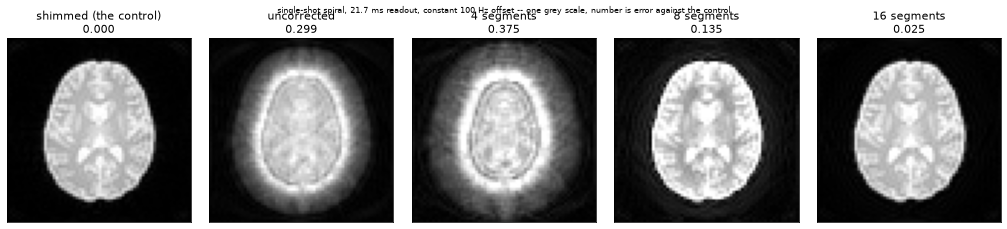

In [7]:
fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 3.5))
ceiling = float(np.percentile(np.abs(shimmed), 99.5))
for ax, (name, image) in zip(axes, panels.items()):
    # same_frame because a non-Cartesian reconstruction is [x, y] -- see the radial notebook's
    # section 2, where the convention is established by a point at a known position.
    ax.imshow(ph.same_frame(np.abs(image)), cmap='gray', origin='lower', vmin=0.0, vmax=ceiling)
    ax.set(title=f'{name}\n{against_shimmed(image):.3f}', xticks=[], yticks=[])
fig.suptitle(f'single-shot spiral, {single.t_adc_s[-1] * 1e3:.1f} ms readout, constant '
             f'{OFFSET_HZ:.0f} Hz offset -- one grey scale, number is error against the control',
             fontsize=9)
fig.tight_layout()

The middle panel is the artefact: a 21.7 ms readout at 100 Hz, and the brain is a blur. Sixteen
segments recover it to 0.025 of the shimmed control — and four segments, again, is *worse* than
leaving it alone.

Nothing about the reconstruction changed between the panels except the number of terms in the
forward model. Same trajectory, same weights, same solver, same iteration count.

---
## What this notebook measured

| | |
|---|---|
| **off-resonance is priced by readout length** | 8 interleaves at 2.73 ms: one voxel stays one pixel at 100 Hz. Single-shot at 21.7 ms: the same voxel spreads over 108. One variable between the rows |
| **the segmented forward model converges to the exact one** | 100 % error at one segment, 7e-3 at sixteen, and a floor there set by the interpolation between segment centres rather than by the count |
| **the correction recovers the point** | 108 pixels to 1, and the peak by more than 10x, at eight segments for 2.17 cycles |
| **too few segments is worse than none** | 210 pixels against 108 uncorrected, because a four-point phase screen aliases 2.17 cycles of phase |
| **and on a brain** | 0.299 uncorrected against the shimmed control, 0.025 with sixteen segments — and the phantom's own milder field costs 0.062, printed beside it |
| **the shared reconstruction path needed no change** | same adapter, same operator, same solve as the radial notebook; `segments` and `b0_hz` were already parameters of it |

**What it does not establish.** That the field map is known — every correction here was given the
*exact* offset that was simulated, and on a scanner it is measured, with its own resolution, noise
and unwrapping failures. Nor anything about gradient delays or trajectory infidelity, which blur a
spiral in a way that looks similar and is fixed by something else entirely; nor $T_2^*$ decay
during the readout, which is also a function of time and is not corrected by a phase screen. Those
are separate measurements and none is made here.

Next: [`../se_spiral_2d/01_build.ipynb`](../se_spiral_2d/01_build.ipynb) puts a refocusing pulse in
front of a spiral, where the question is no longer what the readout costs but **which instant the
echo is aligned to**.